# 1주차 : Tensor 차원 실습

## 금주 목표
* 협업을 위한 Git/GitHub 환경 구축 및 팀 Repository 개설
* 행렬의 곱셈과 차원 변환 학습 및 코드를 라이브러리 없이 구현
    * 행렬의 곱셈과 차원 변환 코드 작성
        * np.dot이나 @연산자를 사용하지 않고, 수학 공식 구현
    * 실제주가 데이터라고 가정한 3D더미텐서 활용 데이터 조작 연습
        * Numpy를 활용하여 이 (128, 30, 5) 형태의 3D 더미 텐서(가짜 주가 데이터)를 만들기
        * 이를 자유자재로 다루는 방법(Slicing) 익히기
    * IRIS와 MNIST를 활용하여 데이터 변환 연습
        * Reshape과 Transpose를 익히기 위해 텐서의 Axis를 뒤집거나 납작하게 펴봄

## 1. 행렬의 곱셈

행렬의 곱셈 구현해보기

In [1]:
import numpy as np

def matmul(A, B):
    # 1. 차원 검증: A의 Column 개수와 B의 Row 개수가 일치해야 함
    if A.shape[1] != B.shape[0]:
        raise ValueError("행렬 차원 불일치")
    
    # 2. 결과 행렬 초기화
    m, n = A.shape
    _, o = B.shape
    C = np.zeros((m, o))
    
    # 3. 3중 for문을 활용한 내적 계산
    for i in range(m):
        for j in range(o):
            for k in range(n):
                C[i, j] += A[i, k] * B[k, j]
                
    return C

실행 및 검증

In [2]:
matrix_A = np.array([[1,2,3],[4,5,6]])
matrix_B = np.array([[7,8],[9,10],[11,12]])

print(f"입력 차원: matrix_A {matrix_A.shape}, matrix_B {matrix_B.shape}")
print(matmul(matrix_A, matrix_B))

입력 차원: matrix_A (2, 3), matrix_B (3, 2)
[[ 58.  64.]
 [139. 154.]]


## 2. 더미데이터 활용 데이터 조작 연습

**np.random.randn**  
평균이 0이고 표준편차가 1인 정규분포 모양의 난수를 만들어내는 함수  
여기서는 매일매일의 주가 변동폭을 의미 (하루치 움직임. 양수: 주가가 오름, 음수: 주가가 떨어짐)  
  
파라미터 np.random.randn(d0, d1, ..., dn)  
* dn : 만들고자 하는 축별 크기

**np.cumsum**  
배열의 데이터들을 누적합으로 더해주는 함수  
여기서는 주식 시장에서 현 주가는 작일의 종가에 오늘 발생한 변동폭이 더해져서 만들어진다는 점을 적용  
계속 누적해서 더해줌으로써, 데이터가 뚝뚝 끊기지 않고 꼬리를 물고 이어짐  
  
파라미터 np.cumsum(a, axis=None)
* a : 누적합을 계산할 대상이 되는 원본 데이터(Numpy 배열)
* axis : 어느 '방향(축)'을 기준으로 더할 건지 결정하는 정수 (더미 데이터 (128, 30, 5)에서 축의 번호는 0=배치, 1=시간, 2=속성)

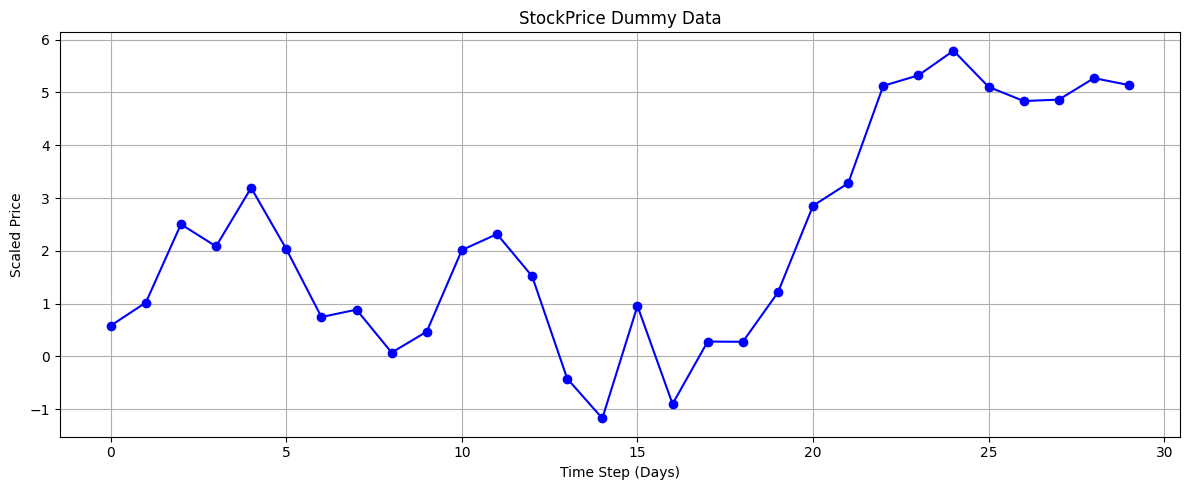

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 텐서 세팅
batch_size = 128  # 한 번에 학습할 샘플 묶음의 크기
time_steps = 30   # 모델이 바라볼 과거 기간 (30일)
features = 5      # 각 일자별 속성 개수 (Open, High, Low, Close, Volume)


# 2. 데이터 생성 : 랜덤 변화량을 '누적합(cumsum)'하여 추세 생성
# 주식은 어제의 가격에 오늘의 변동폭이 더해지는 구조이므로 누적합을 사용
steps = np.random.randn(batch_size, time_steps, features)   # 매일의 변동폭
data = np.cumsum(steps, axis=1)                             # 시간(axis=1) 축을 따라 누적합 계산

# 3. Matplotlib 시각화
# 첫 번째 배치(index 0)의 30일 치 '종가(Close, 3번 인덱스)'만 가져와서 비교
close = data[0, :, 3]
plt.figure(figsize=(12, 5))
plt.plot(close, marker='o', color='blue', linestyle='-')
plt.title("StockPrice Dummy Data")
plt.xlabel("Time Step (Days)")
plt.ylabel("Scaled Price")
plt.grid(True)

plt.tight_layout()
plt.show()

첫 번째 배치(0번 인덱스)의 전체 데이터만 가져오기

In [4]:
first_batch_data = data[0, :, :]
print(f"첫 번째 배치의 형태: {first_batch_data.shape}") # (30, 5) -> 30일 치의 5개 속성

첫 번째 배치의 형태: (30, 5)


전체 배치에 대해, 가장 최근 날짜(마지막 날, 29번 인덱스)의 데이터만 가져오기

In [5]:
latest_day_data = data[:, -1, :]
print(f"마지막 날짜 데이터 형태: {latest_day_data.shape}") # (128, 5)

마지막 날짜 데이터 형태: (128, 5)


첫 번째 배치의 30일 치 데이터 중, '종가(Close, 3번 인덱스 가정)'만 쏙 뽑아내기

In [6]:
first_batch_close_prices = data[0, :, 3]
print(f"첫 번째 배치의 30일 치 종가 형태: {first_batch_close_prices.shape}") # (30,)

첫 번째 배치의 30일 치 종가 형태: (30,)


## 3. 실데이터를 이용한 변환 연습(IRIS와 MNIST)

IRIS 데이터 차원 변환 (2D -> 3D)  
**순수하게 차원을 늘려보는 데에만 의의를 둠. 차원을 확장한 데이터에는 아무의미도 없음)**

데이터 불러오기

In [7]:
import numpy as np
from sklearn.datasets import load_iris

# 1. 데이터 로드 및 확인
iris = load_iris()
iris_data = iris.data  # 기본 형태: 150개의 꽃 샘플, 4개의 특징
print(f"원본 IRIS 차원: {iris_data.shape}")

원본 IRIS 차원: (150, 4)


**np.reshape**  
데이터가 메모리에 저장된 순서는 그대로 둔 채, 배열을 끊어 읽는 단위(그릇의 형태)만 바꾸는 함수  
여기서는 2차원 형태(날짜, 속성)로 수집된 엑셀 표 같은 주가 데이터를 모델에 넣기 위해   
3차원 형태(배치, 시간, 속성)로 규격을 맞춰 포장하거나, 1차원 벡터로 평탄화(Flatten)할 때 사용할것을 가정  
  
파라미터 a.reshape(newshape)  
* a : 형태를 변환할 원본 데이터(Numpy 배열)
* newshape : 변환하고자 하는 새로운 차원의 크기 (정수 나열 또는 튜플)

In [8]:
# 2. 시계열 데이터 모사를 위한 Reshape
# 150개 중 120개만 슬라이싱하여 (Batch, Time_step, Feature) 형태로 변환
sliced_iris = iris_data[:120]
reshaped_iris = sliced_iris.reshape(12, 10, 4) 
print(f"Reshape 후 (12배치, 10일치, 4피처): {reshaped_iris.shape}")

Reshape 후 (12배치, 10일치, 4피처): (12, 10, 4)


**np.transpose**  
데이터의 Axis 자체를 맞교환하여 내부 데이터의 배열 순서를 뒤집어 재정렬하는 함수  
여기서는 우리가 크롤링한 시계열 데이터 구조를,   
우리가 만든 딥러닝 모델이 요구하는 입력 순서인에 맞게 강제로 축을 비틀어 던져줄 때 사용  
Ex. (배치, 시간, 속성) -> (배치, 속성, 시간)   

파라미터 a.transpose(axes=None)
* a : 축을 변환할 원본 데이터(Numpy 배열)
* axes : 기존 축의 인덱스 번호를 새롭게 재배치할 순서대로 나열한 튜플. (ex. (0, 1, 2) 순서인 기존 3D 텐서에 axes=(0, 2, 1)을 부여하면 시간(1번 축)과 속성(2번 축)의 자리가 서로 맞교환됨)

In [9]:
# 3. Transpose (축 교환)
# 1번 축(Time)과 2번 축(Feature)의 자리를 바꿈
transposed_iris = reshaped_iris.transpose(0, 2, 1)
print(f"Transpose 후 (12배치, 4피처, 10일치): {transposed_iris.shape}")

Transpose 후 (12배치, 4피처, 10일치): (12, 4, 10)
